# Deep Learning: Multi-Class Image Classification with CNN from Scratch
**Dataset:** CIFAR-10 | **Framework:** PyTorch | **Model:** Custom CNN (IntelCNN)

---

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import time, copy, warnings
warnings.filterwarnings('ignore')

# Device setup - works on both CPU and CUDA
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# CIFAR-10 class names
CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

Using device: cuda


## 2. Dataset Loading

In [2]:
# Download CIFAR-10 dataset
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

# Training transforms with data augmentation
train_tf = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Test/Val transforms - no augmentation
test_tf = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Load datasets
full_train = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_tf)
test_data  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)

# Split train into train/val (45K / 5K)
train_data, val_data = random_split(full_train, [45000, 5000],
                                     generator=torch.Generator().manual_seed(42))

print(f"Train size: {len(train_data)}")
print(f"Val size:   {len(val_data)}")
print(f"Test size:  {len(test_data)}")

100%|██████████| 170M/170M [00:17<00:00, 9.93MB/s]


Train size: 45000
Val size:   5000
Test size:  10000


## 3. Preprocessing & Data Loaders

Batch shape: torch.Size([64, 3, 32, 32])


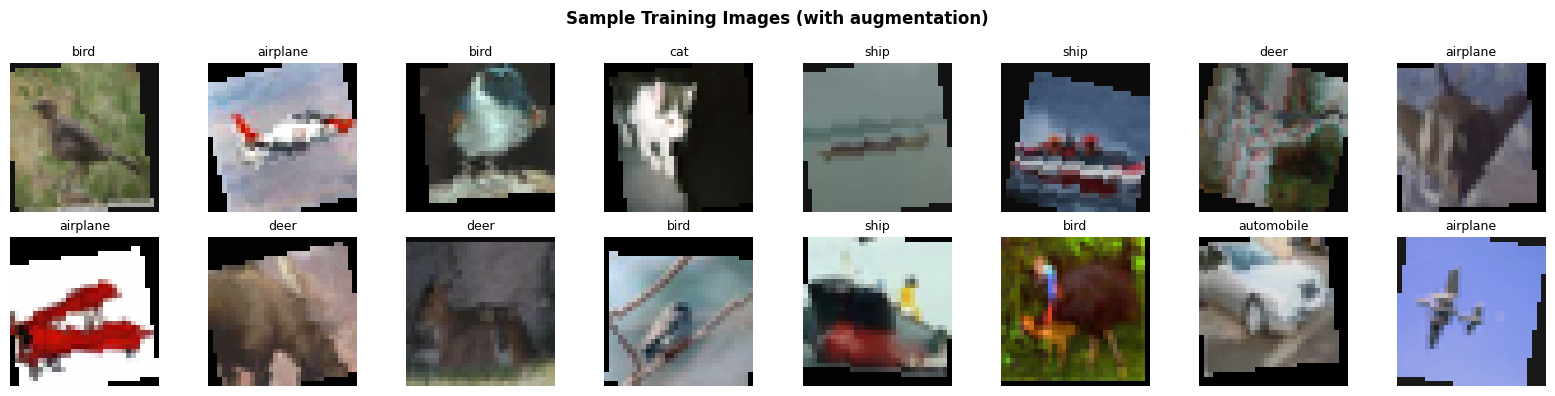

In [3]:
BATCH_SIZE = 64

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# Preview sample images
imgs, lbls = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}")

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = imgs[i].permute(1, 2, 0).numpy()
    img = img * np.array(STD) + np.array(MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(CLASSES[lbls[i]], fontsize=9)
    ax.axis('off')
plt.suptitle("Sample Training Images (with augmentation)", fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Model Architecture (CNN from Scratch)

In [4]:
class IntelCNN(nn.Module):
    """
    Custom CNN built from scratch for CIFAR-10.
    4 convolutional blocks with BatchNorm, ReLU, MaxPooling, and Dropout.
    """
    def __init__(self, num_classes=10, dropout_rate=0.3):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: 3 -> 64 channels
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),

            # Block 2: 64 -> 128 channels
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),

            # Block 3: 128 -> 256 channels
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),

            # Block 4: 256 -> 512 channels
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Dropout2d(0.35),
        )

        # Classifier head (Dense layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = IntelCNN(num_classes=10, dropout_rate=0.3).to(DEVICE)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)

Total parameters: 4,823,626
IntelCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.2, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, 

## 5. Training

In [5]:
def train_model(model, train_ldr, val_ldr, epochs=30, lr=0.001, patience=7, device=DEVICE):
    """Train with early stopping. Works on both CPU and CUDA."""
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr*3, steps_per_epoch=len(train_ldr), epochs=epochs)

    best_acc, wait = 0, 0
    best_wts = None
    hist = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    t0 = time.time()

    for ep in range(epochs):
        # --- Train ---
        model.train()
        tl, tc, tt = 0.0, 0, 0
        for x, y in train_ldr:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            scheduler.step()
            tl += loss.item()
            tc += out.argmax(1).eq(y).sum().item()
            tt += y.size(0)

        # --- Validate ---
        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_ldr:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                vl += loss.item()
                vc += out.argmax(1).eq(y).sum().item()
                vt += y.size(0)

        ta = 100.0 * tc / tt
        va = 100.0 * vc / vt
        hist['train_loss'].append(tl / len(train_ldr))
        hist['train_acc'].append(ta)
        hist['val_loss'].append(vl / len(val_ldr))
        hist['val_acc'].append(va)

        tag = ""
        if va > best_acc:
            best_acc = va
            wait = 0
            best_wts = copy.deepcopy(model.state_dict())
            tag = " [BEST]"
        else:
            wait += 1

        lr_now = scheduler.get_last_lr()[0]
        print(f"Epoch {ep+1:02d}/{epochs} | Train: {ta:.1f}% | Val: {va:.1f}% | LR: {lr_now:.6f}{tag}")

        if wait >= patience:
            print(f"Early stopping at epoch {ep+1}")
            break

    elapsed = (time.time() - t0) / 60
    print(f"\nDone in {elapsed:.1f} min | Best val acc: {best_acc:.2f}%")
    if best_wts:
        model.load_state_dict(best_wts)
    return hist, best_acc

In [6]:
# Train the baseline model
history, best_acc = train_model(model, train_loader, val_loader, epochs=30, lr=0.001, patience=7)

Epoch 01/30 | Train: 31.8% | Val: 43.6% | LR: 0.000207 [BEST]
Epoch 02/30 | Train: 44.8% | Val: 53.7% | LR: 0.000457 [BEST]
Epoch 03/30 | Train: 51.9% | Val: 59.7% | LR: 0.000840 [BEST]
Epoch 04/30 | Train: 56.5% | Val: 62.3% | LR: 0.001310 [BEST]
Epoch 05/30 | Train: 59.7% | Val: 65.6% | LR: 0.001810 [BEST]
Epoch 06/30 | Train: 63.2% | Val: 66.1% | LR: 0.002280 [BEST]
Epoch 07/30 | Train: 65.5% | Val: 72.1% | LR: 0.002663 [BEST]
Epoch 08/30 | Train: 68.0% | Val: 70.9% | LR: 0.002913
Epoch 09/30 | Train: 70.1% | Val: 75.4% | LR: 0.003000 [BEST]
Epoch 10/30 | Train: 71.8% | Val: 76.1% | LR: 0.002983 [BEST]
Epoch 11/30 | Train: 73.2% | Val: 77.6% | LR: 0.002933 [BEST]
Epoch 12/30 | Train: 74.9% | Val: 79.2% | LR: 0.002851 [BEST]
Epoch 13/30 | Train: 76.0% | Val: 79.9% | LR: 0.002739 [BEST]
Epoch 14/30 | Train: 76.9% | Val: 80.1% | LR: 0.002599 [BEST]
Epoch 15/30 | Train: 77.9% | Val: 80.7% | LR: 0.002435 [BEST]
Epoch 16/30 | Train: 78.9% | Val: 81.9% | LR: 0.002250 [BEST]
Epoch 17/30 | T

## 6. Hyperparameter Experiments
Train the model independently for each configuration and collect full metrics.

In [7]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

# ─── Experiment definitions ────────────────────────────────────────────────
experiments = [
    {"name": "LR=0.1, BS=64",    "lr": 0.1,    "bs": 64,  "epochs": 10},
    {"name": "LR=0.0005, BS=64", "lr": 0.0005, "bs": 64,  "epochs": 10},
    {"name": "LR=0.001, BS=32",  "lr": 0.001,  "bs": 32,  "epochs": 10},
    {"name": "LR=0.001, BS=128", "lr": 0.001,  "bs": 128, "epochs": 10},
]

# ─── Helper: evaluate a trained model and return weighted Precision/Recall/F1 ─
def evaluate_metrics(model, val_ldr, device=DEVICE):
    model.eval()
    all_preds, all_labels = [], []
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    total_loss, total = 0.0, 0

    with torch.no_grad():
        for x, y in val_ldr:
            x, y = x.to(device), y.to(device)
            out  = model(x)
            loss = criterion(out, y)
            total_loss += loss.item()
            preds = out.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            total += y.size(0)

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    avg_loss   = total_loss / len(val_ldr)
    accuracy   = 100.0 * (all_preds == all_labels).mean()
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, accuracy, prec, rec, f1

# ─── Run experiments ───────────────────────────────────────────────────────
results = []   # list of dicts, one per experiment

for cfg in experiments:
    print(f"\n{'='*60}")
    print(f"  Experiment : {cfg['name']}  |  Epochs: {cfg['epochs']}")
    print(f"{'='*60}")

    # Build data loaders for this batch size
    ldr_tr = DataLoader(train_data, batch_size=cfg['bs'],
                        shuffle=True, num_workers=0, pin_memory=True)
    ldr_vl = DataLoader(val_data,   batch_size=cfg['bs'],
                        shuffle=False, num_workers=0, pin_memory=True)

    # Fresh model per experiment
    exp_model = IntelCNN(num_classes=10).to(DEVICE)

    # Train (reuse existing train_model function)
    h, _ = train_model(exp_model, ldr_tr, ldr_vl,
                       epochs=cfg['epochs'], lr=cfg['lr'], patience=cfg['epochs'])

    # Full metric evaluation on validation set
    val_loss, val_acc, prec, rec, f1 = evaluate_metrics(exp_model, ldr_vl)

    # Store everything
    results.append({
        "name":          cfg['name'],
        "lr":            cfg['lr'],
        "batch_size":    cfg['bs'],
        "train_loss":    h['train_loss'][-1],
        "val_loss":      val_loss,
        "train_acc":     h['train_acc'][-1],
        "val_acc":       val_acc,
        "precision":     prec,
        "recall":        rec,
        "f1_score":      f1,
        "history":       h,
    })

    del exp_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n✅ All experiments completed.")



  Experiment : LR=0.1, BS=64  |  Epochs: 10
Epoch 01/10 | Train: 23.5% | Val: 27.0% | LR: 0.084062 [BEST]
Epoch 02/10 | Train: 21.1% | Val: 13.3% | LR: 0.228124
Epoch 03/10 | Train: 14.7% | Val: 17.7% | LR: 0.300000
Epoch 04/10 | Train: 14.6% | Val: 16.0% | LR: 0.285104
Epoch 05/10 | Train: 10.1% | Val: 9.4% | LR: 0.243449
Epoch 06/10 | Train: 9.9% | Val: 10.1% | LR: 0.183285
Epoch 07/10 | Train: 10.1% | Val: 10.2% | LR: 0.116529
Epoch 08/10 | Train: 9.8% | Val: 10.6% | LR: 0.056403
Epoch 09/10 | Train: 10.0% | Val: 10.6% | LR: 0.014814
Epoch 10/10 | Train: 9.7% | Val: 10.1% | LR: 0.000001

Done in 9.1 min | Best val acc: 26.96%

  Experiment : LR=0.0005, BS=64  |  Epochs: 10
Epoch 01/10 | Train: 29.2% | Val: 40.8% | LR: 0.000420 [BEST]
Epoch 02/10 | Train: 43.6% | Val: 51.0% | LR: 0.001141 [BEST]
Epoch 03/10 | Train: 52.4% | Val: 57.7% | LR: 0.001500 [BEST]
Epoch 04/10 | Train: 58.5% | Val: 64.9% | LR: 0.001426 [BEST]
Epoch 05/10 | Train: 63.3% | Val: 67.4% | LR: 0.001217 [BEST]
Epoc

## 6a. Summary Table


In [8]:
# ─── Build a tidy summary DataFrame ───────────────────────────────────────
metrics_df = pd.DataFrame([{
    "Experiment":     r['name'],
    "LR":             r['lr'],
    "Batch Size":     r['batch_size'],
    "Train Loss":     round(r['train_loss'], 4),
    "Val Loss":       round(r['val_loss'],   4),
    "Train Acc (%)":  round(r['train_acc'],  2),
    "Val Acc (%)":    round(r['val_acc'],     2),
    "Precision":      round(r['precision'],   4),
    "Recall":         round(r['recall'],      4),
    "F1-Score":       round(r['f1_score'],    4),
} for r in results])

print("=" * 95)
print("                        HYPERPARAMETER EXPERIMENT SUMMARY")
print("=" * 95)
print(metrics_df.to_string(index=False))
print("=" * 95)


                        HYPERPARAMETER EXPERIMENT SUMMARY
      Experiment     LR  Batch Size  Train Loss  Val Loss  Train Acc (%)  Val Acc (%)  Precision  Recall  F1-Score
   LR=0.1, BS=64 0.1000          64      2.3032    1.9740           9.66        26.76     0.2317  0.2676    0.2173
LR=0.0005, BS=64 0.0005          64      1.0475    0.9576          76.30        79.12     0.7889  0.7912    0.7892
 LR=0.001, BS=32 0.0010          32      1.0499    0.9446          76.40        80.34     0.8020  0.8034    0.8016
LR=0.001, BS=128 0.0010         128      1.0286    0.9373          77.08        80.12     0.7995  0.8012    0.7996


## 6b. Comparison Graphs Across Experiments


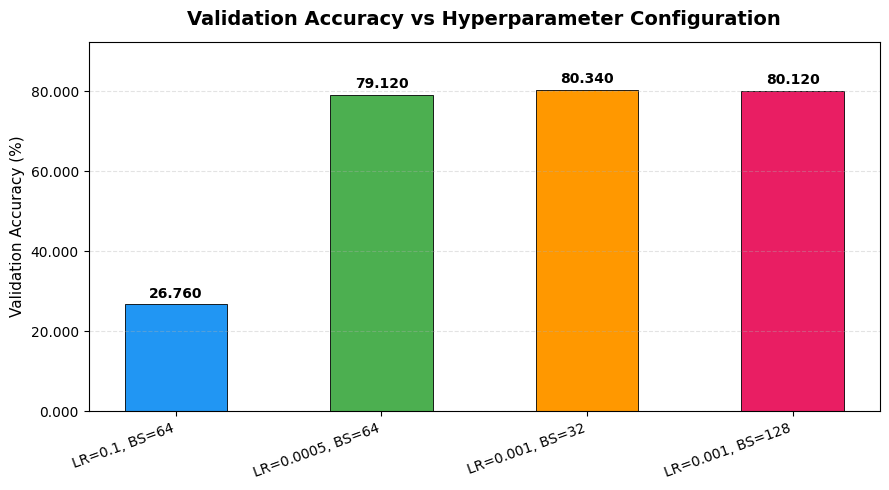

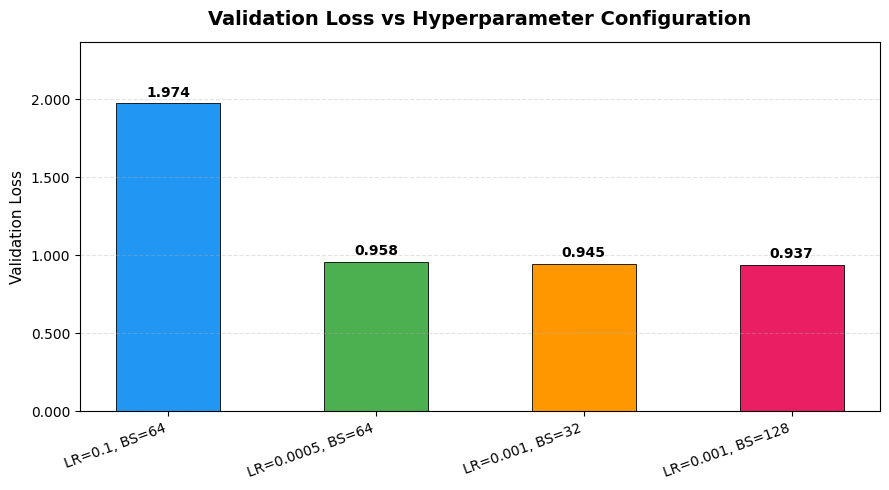

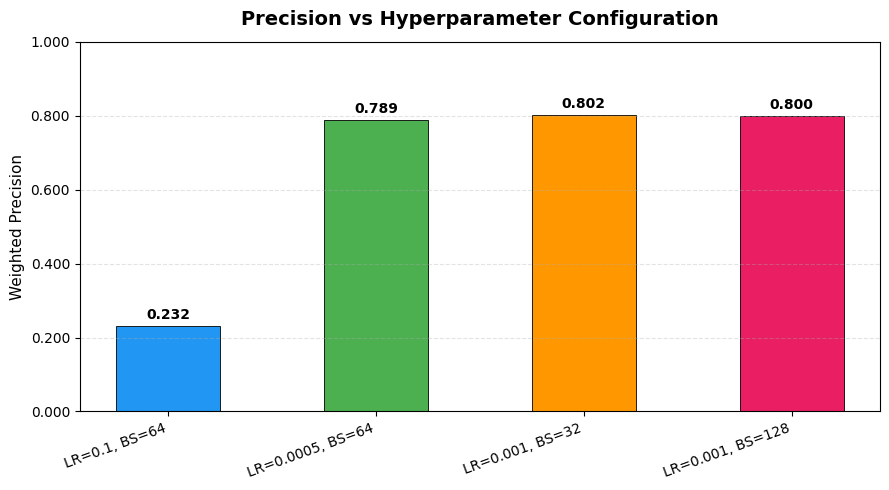

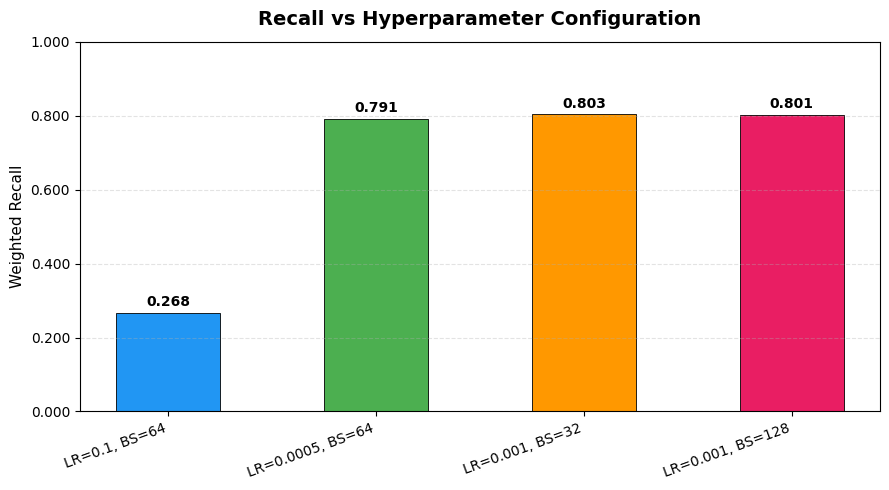

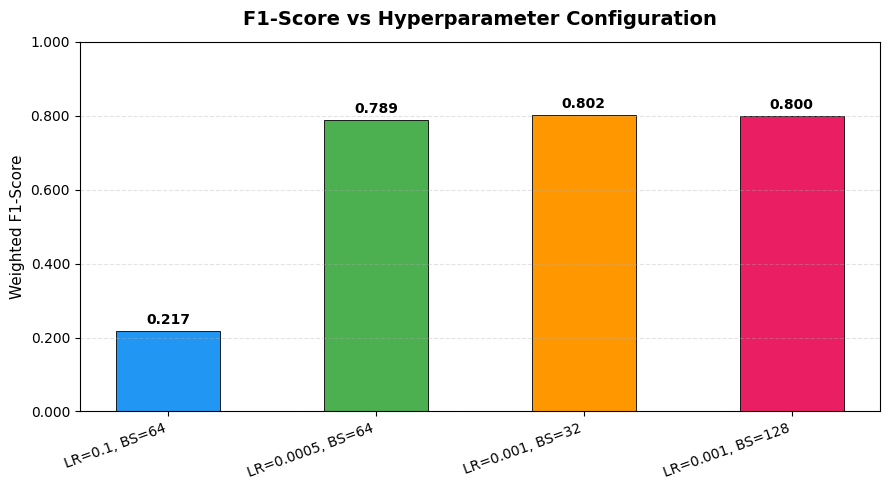

In [9]:
import matplotlib.ticker as mticker

names   = [r['name'] for r in results]
x       = np.arange(len(names))
palette = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

def bar_chart(values, title, ylabel, color_list, y_lo=None, y_hi=None):
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(x, values, color=color_list, edgecolor='black', linewidth=0.6, width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha='right', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    if y_lo is not None:
        ax.set_ylim(y_lo, y_hi)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    ax.grid(axis='y', alpha=0.35, linestyle='--')
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width() / 2,
                b.get_height() + (y_hi - y_lo) * 0.01 if y_lo is not None else b.get_height() * 1.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 1. Validation Accuracy
bar_chart(
    [r['val_acc'] for r in results],
    'Validation Accuracy vs Hyperparameter Configuration',
    'Validation Accuracy (%)', palette,
    y_lo=0, y_hi=max(r['val_acc'] for r in results) * 1.15
)

# 2. Validation Loss
bar_chart(
    [r['val_loss'] for r in results],
    'Validation Loss vs Hyperparameter Configuration',
    'Validation Loss', palette,
    y_lo=0, y_hi=max(r['val_loss'] for r in results) * 1.2
)

# 3. Precision
bar_chart(
    [r['precision'] for r in results],
    'Precision vs Hyperparameter Configuration',
    'Weighted Precision', palette,
    y_lo=0, y_hi=1.0
)

# 4. Recall
bar_chart(
    [r['recall'] for r in results],
    'Recall vs Hyperparameter Configuration',
    'Weighted Recall', palette,
    y_lo=0, y_hi=1.0
)

# 5. F1-Score
bar_chart(
    [r['f1_score'] for r in results],
    'F1-Score vs Hyperparameter Configuration',
    'Weighted F1-Score', palette,
    y_lo=0, y_hi=1.0
)


## 6c. Training Curves per Experiment


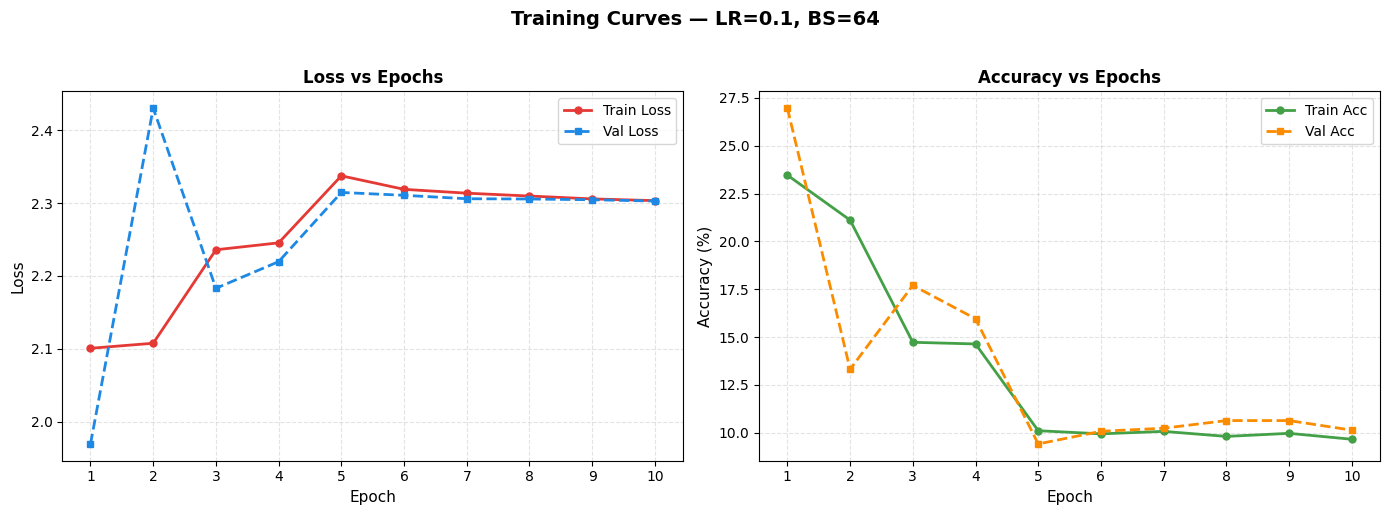

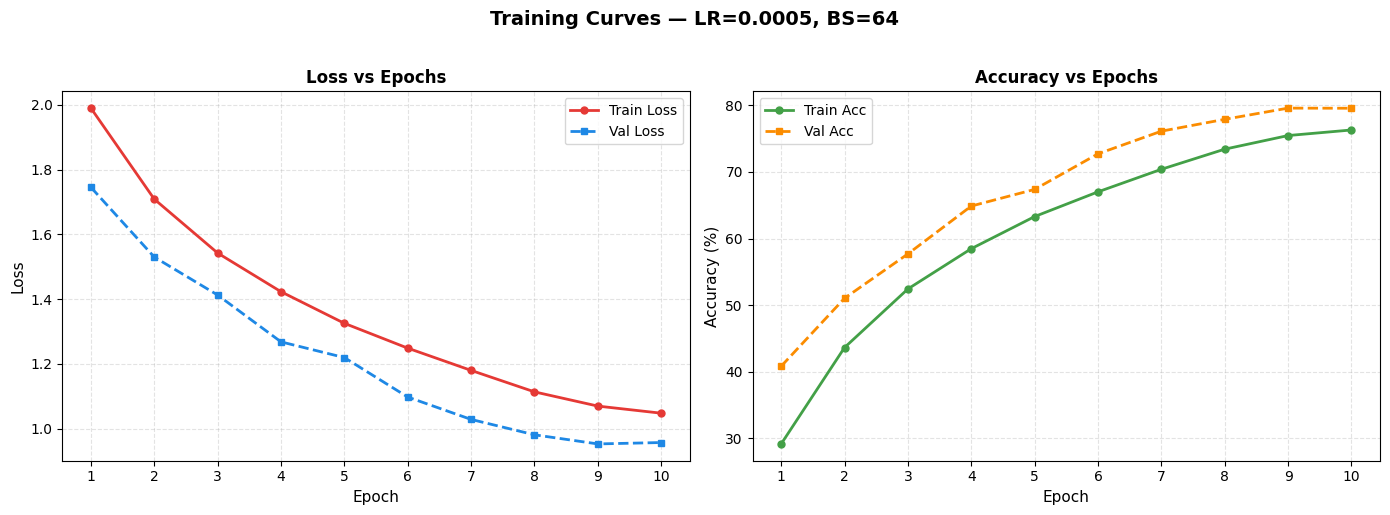

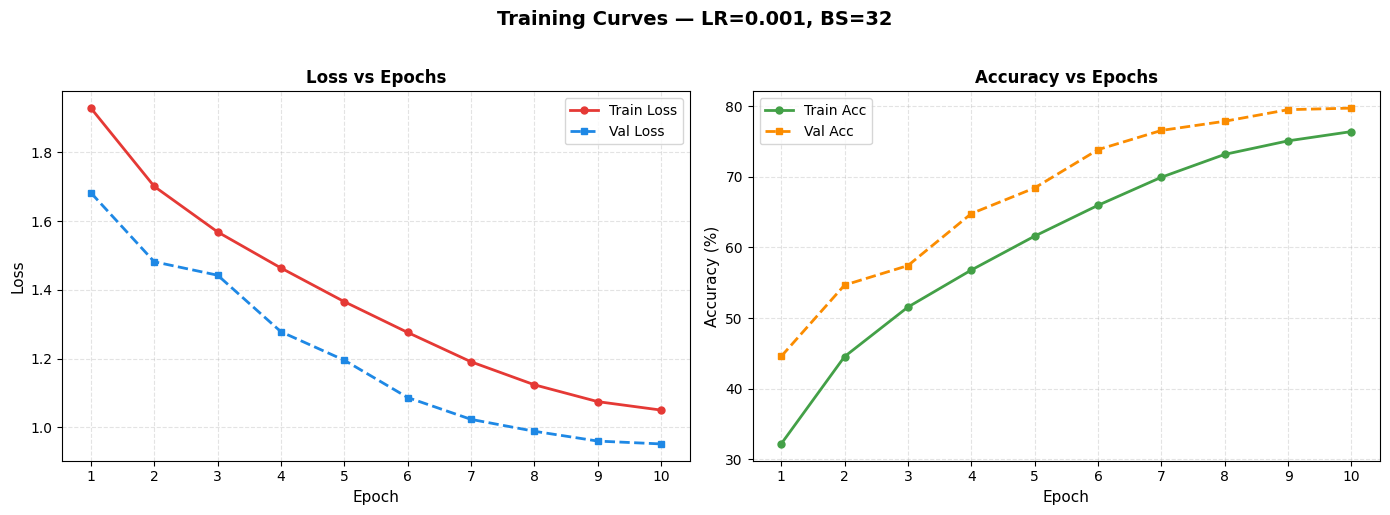

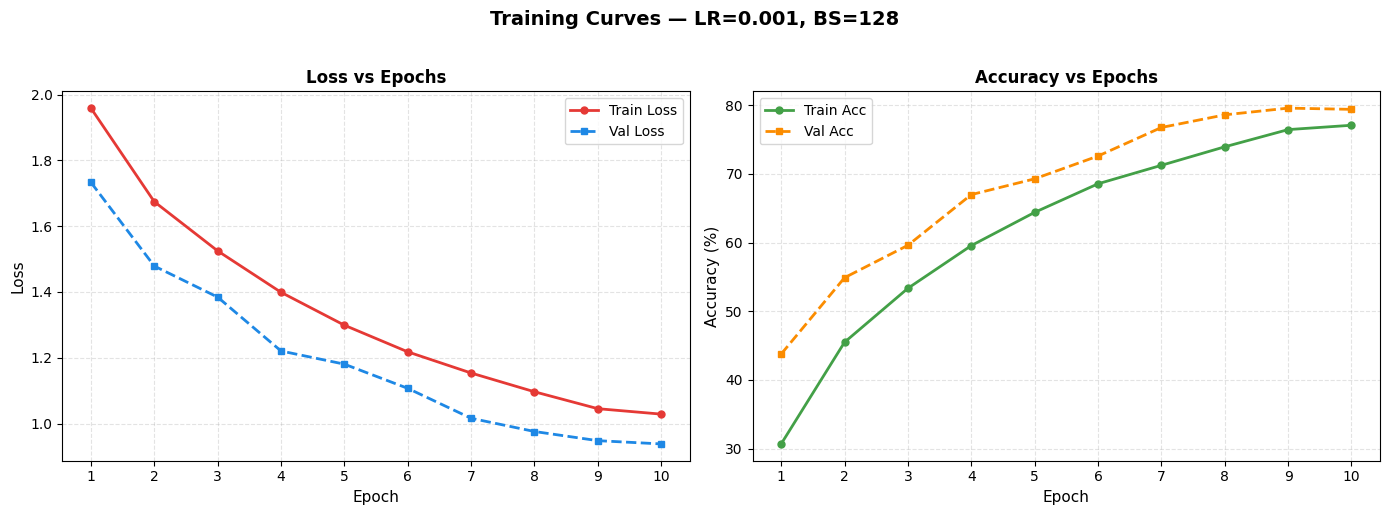

In [10]:
def plot_training_curves(result):
    h    = result['history']
    name = result['name']
    eps  = range(1, len(h['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training Curves — {name}', fontsize=14, fontweight='bold', y=1.02)

    # Loss
    axes[0].plot(eps, h['train_loss'], 'o-', label='Train Loss',
                 color='#E53935', lw=2, markersize=5)
    axes[0].plot(eps, h['val_loss'],   's--', label='Val Loss',
                 color='#1E88E5', lw=2, markersize=5)
    axes[0].set_title('Loss vs Epochs', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('Loss', fontsize=11)
    axes[0].legend(fontsize=10)
    axes[0].grid(alpha=0.35, linestyle='--')
    axes[0].set_xticks(eps)

    # Accuracy
    axes[1].plot(eps, h['train_acc'], 'o-', label='Train Acc',
                 color='#43A047', lw=2, markersize=5)
    axes[1].plot(eps, h['val_acc'],   's--', label='Val Acc',
                 color='#FB8C00', lw=2, markersize=5)
    axes[1].set_title('Accuracy vs Epochs', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('Accuracy (%)', fontsize=11)
    axes[1].legend(fontsize=10)
    axes[1].grid(alpha=0.35, linestyle='--')
    axes[1].set_xticks(eps)

    plt.tight_layout()
    plt.show()

for r in results:
    plot_training_curves(r)


## 6d. Overlay Training Curves — All Experiments


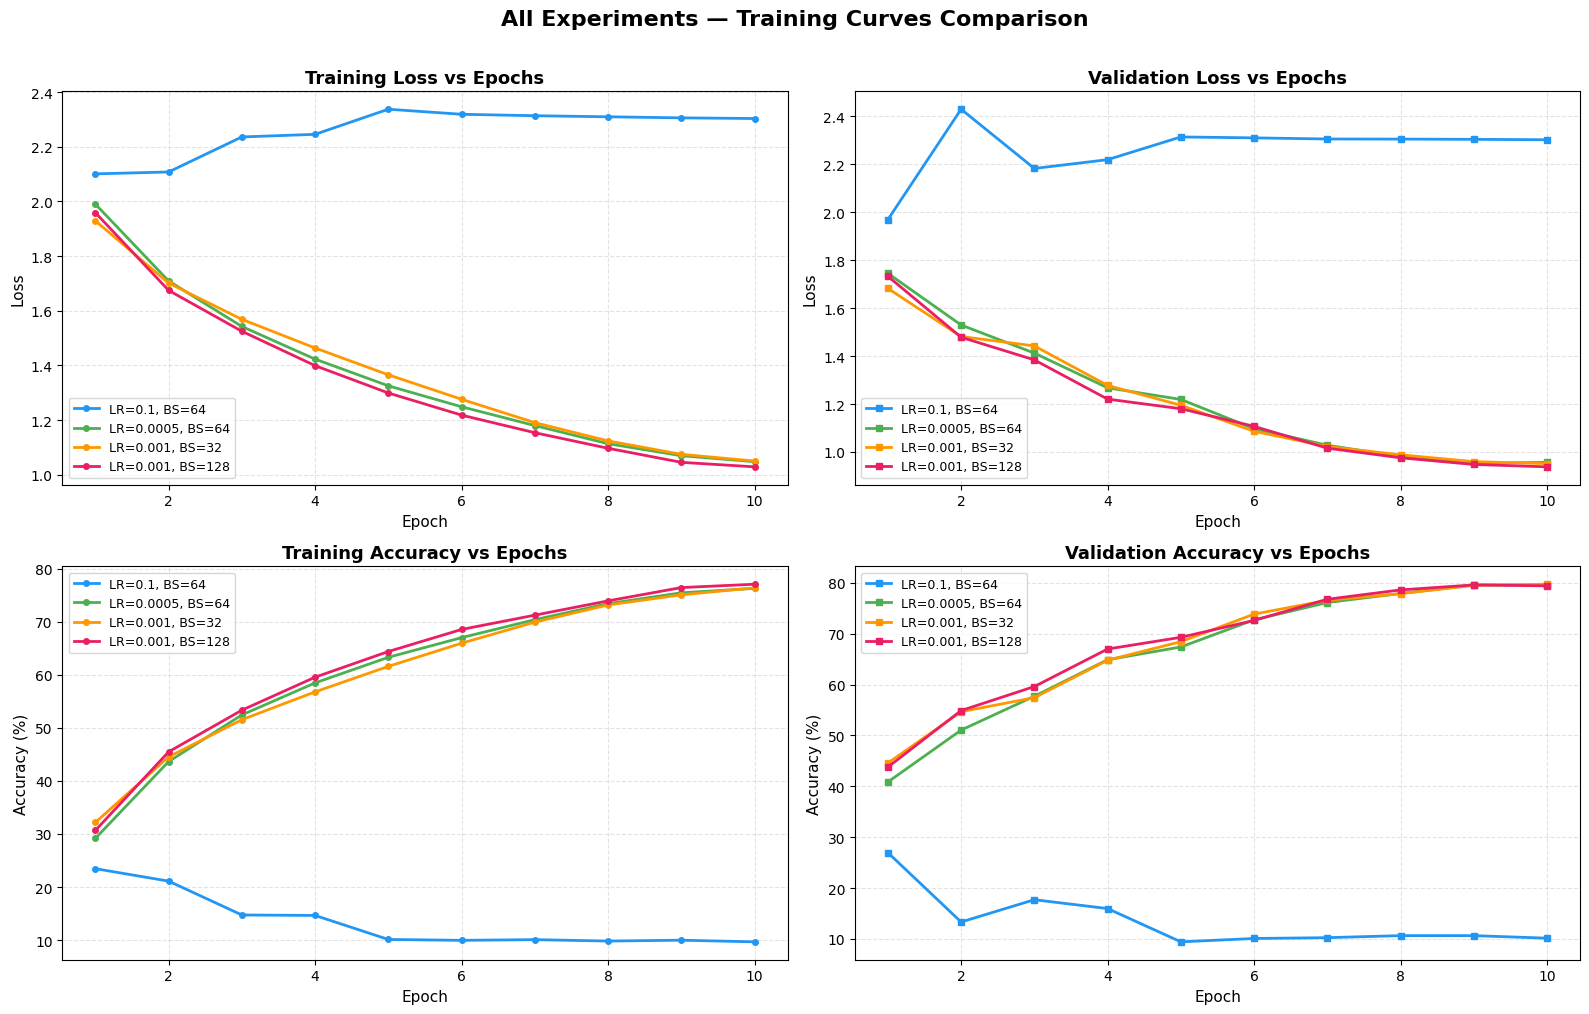

In [11]:
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('All Experiments — Training Curves Comparison',
             fontsize=16, fontweight='bold', y=1.01)

for idx, r in enumerate(results):
    h   = r['history']
    eps = range(1, len(h['train_loss']) + 1)
    c   = colors[idx % len(colors)]

    # Training Loss
    axes[0, 0].plot(eps, h['train_loss'], '-o', label=r['name'], color=c, lw=2, markersize=4)
    # Validation Loss
    axes[0, 1].plot(eps, h['val_loss'],   '-s', label=r['name'], color=c, lw=2, markersize=4)
    # Training Accuracy
    axes[1, 0].plot(eps, h['train_acc'],  '-o', label=r['name'], color=c, lw=2, markersize=4)
    # Validation Accuracy
    axes[1, 1].plot(eps, h['val_acc'],    '-s', label=r['name'], color=c, lw=2, markersize=4)

titles = ['Training Loss vs Epochs', 'Validation Loss vs Epochs',
          'Training Accuracy vs Epochs', 'Validation Accuracy vs Epochs']
ylabels = ['Loss', 'Loss', 'Accuracy (%)', 'Accuracy (%)']

for ax, title, ylabel in zip(axes.flat, titles, ylabels):
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=9, loc='best')
    ax.grid(alpha=0.35, linestyle='--')

plt.tight_layout()
plt.show()


## 7. Evaluation & Metrics

In [12]:
# Evaluate on test set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        preds = model(x).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification report
print("=" * 60)
print("         CLASSIFICATION REPORT (Test Set)")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

# Per-class metrics
prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None)
overall_acc = (all_preds == all_labels).mean()
print(f"Overall Test Accuracy: {overall_acc*100:.2f}%")

         CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

    airplane     0.8803    0.9120    0.8959      1000
  automobile     0.9409    0.9550    0.9479      1000
        bird     0.8892    0.8350    0.8613      1000
         cat     0.8213    0.7080    0.7605      1000
        deer     0.9130    0.8920    0.9024      1000
         dog     0.7963    0.8600    0.8269      1000
        frog     0.9367    0.9180    0.9273      1000
       horse     0.8856    0.9370    0.9106      1000
        ship     0.9378    0.9350    0.9364      1000
       truck     0.8996    0.9500    0.9241      1000

    accuracy                         0.8902     10000
   macro avg     0.8901    0.8902    0.8893     10000
weighted avg     0.8901    0.8902    0.8893     10000

Overall Test Accuracy: 89.02%


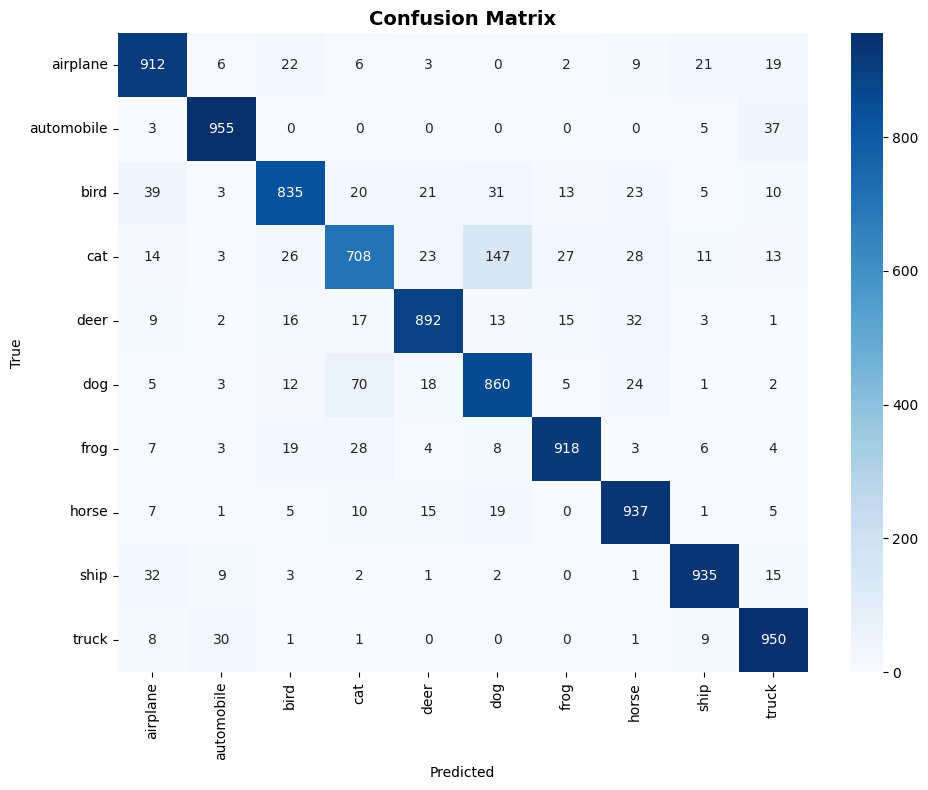

In [13]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

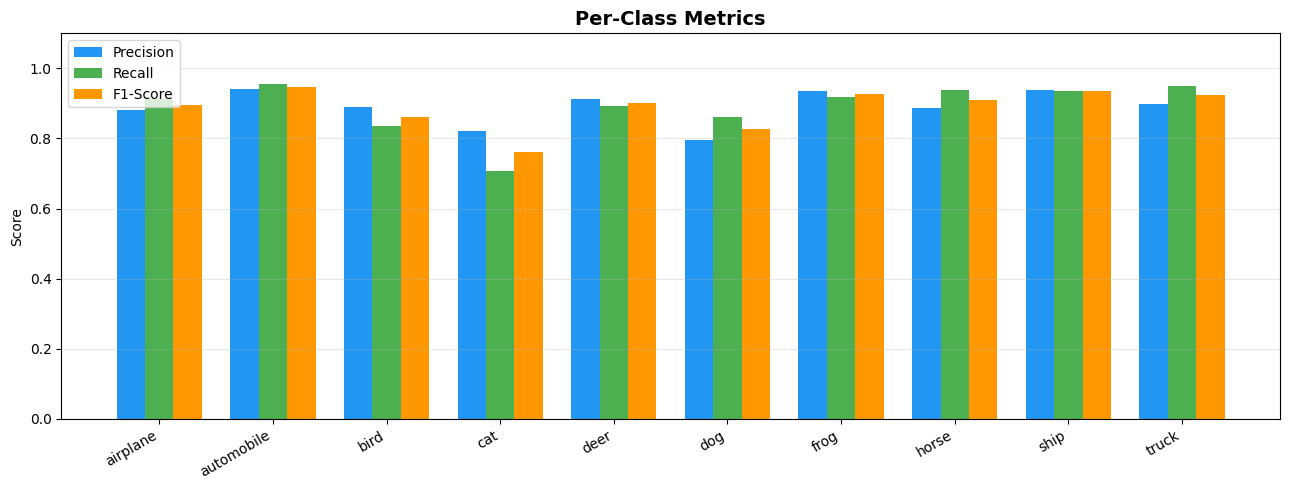

In [14]:
# Per-class precision / recall / F1
x = np.arange(len(CLASSES))
w = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w, prec, w, label='Precision', color='#2196F3')
ax.bar(x,     rec,  w, label='Recall',    color='#4CAF50')
ax.bar(x + w, f1,   w, label='F1-Score',  color='#FF9800')
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=30, ha='right')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.1)
ax.set_title('Per-Class Metrics', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Training vs Validation Curves

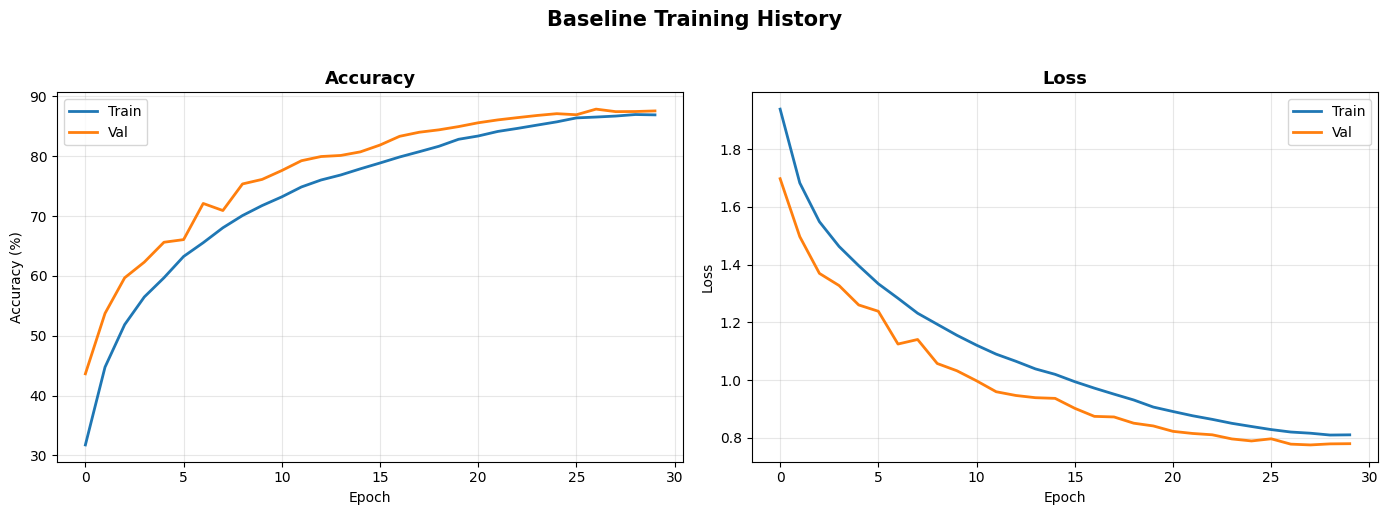

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_acc'], label='Train', lw=2)
axes[0].plot(history['val_acc'],   label='Val',   lw=2)
axes[0].set_title('Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_loss'], label='Train', lw=2)
axes[1].plot(history['val_loss'],   label='Val',   lw=2)
axes[1].set_title('Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Baseline Training History', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

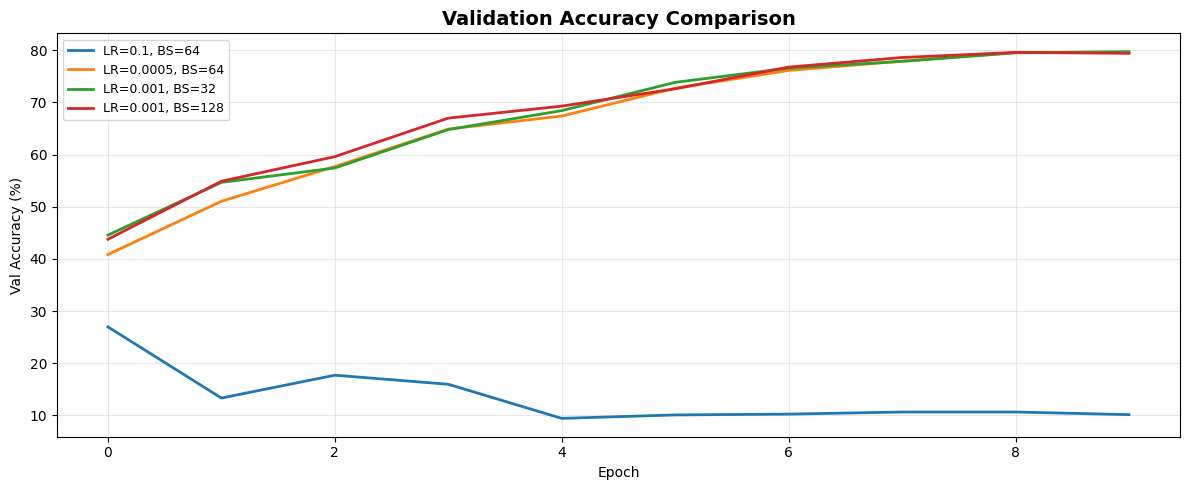

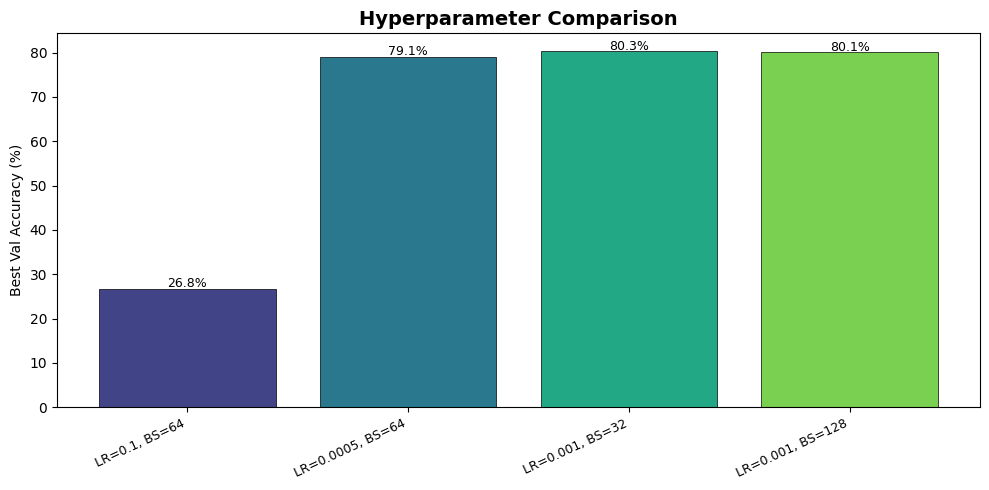

In [16]:
# Compare experiments
fig, ax = plt.subplots(figsize=(12, 5))
for r in results:
    ax.plot(r['history']['val_acc'], label=r['name'], lw=2)
ax.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy (%)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Bar chart
names = [r['name'] for r in results]
accs  = [r['val_acc'] for r in results]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(names)))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(names)), accs, color=colors, edgecolor='black', lw=0.5)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Best Val Accuracy (%)')
ax.set_title('Hyperparameter Comparison', fontsize=14, fontweight='bold')
for b, a in zip(bars, accs):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{a:.1f}%', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## 9. Prediction Visualization
Show input images with true and predicted labels.

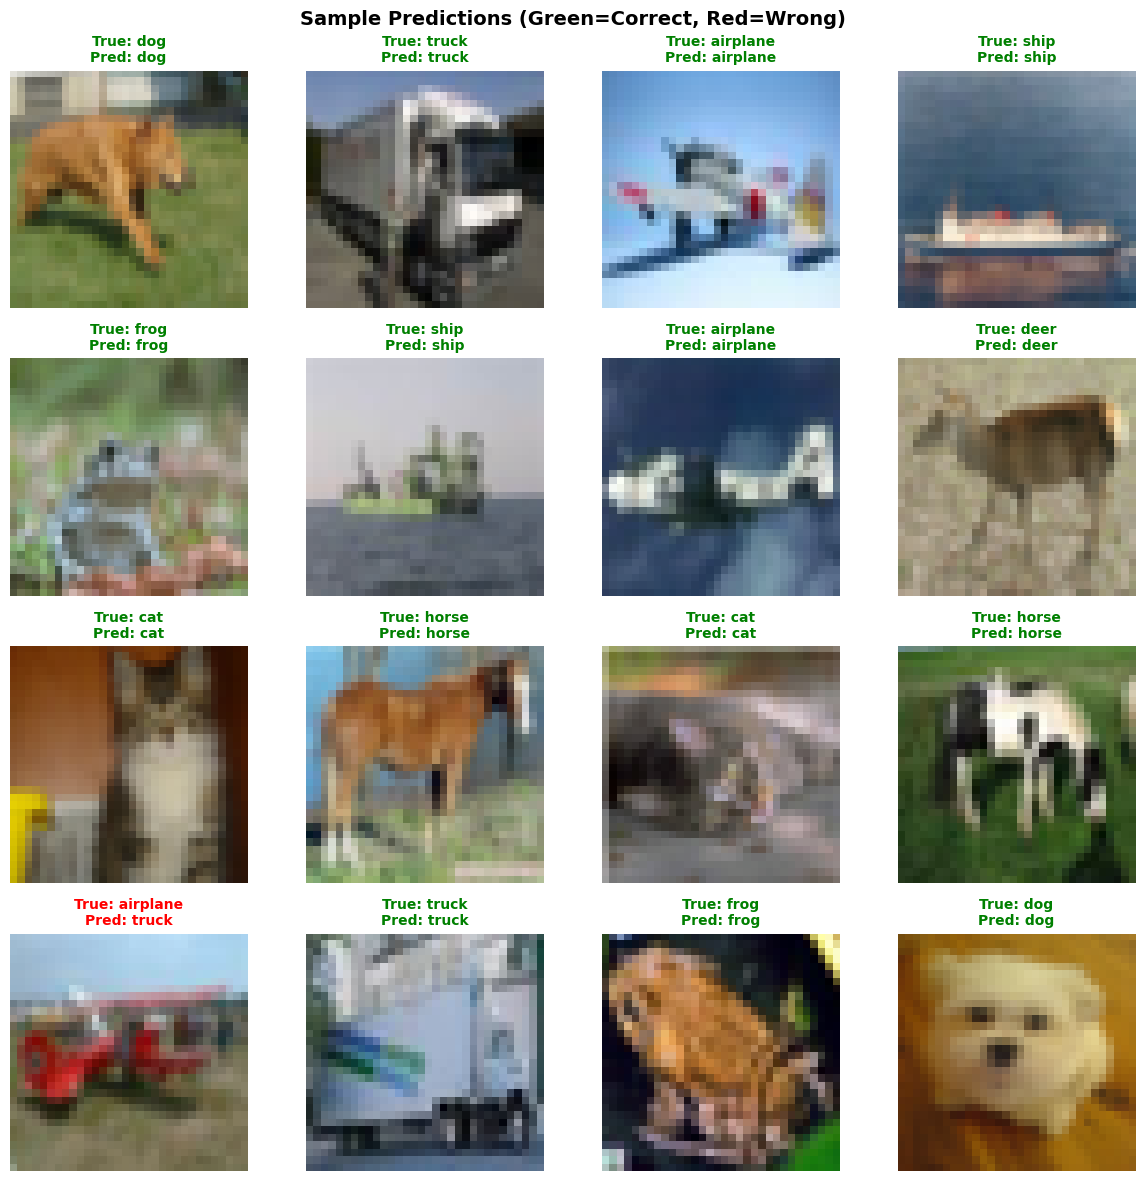

In [17]:
# Load test set without augmentation for visualization
test_vis = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=test_tf)

model.eval()
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
indices = np.random.choice(len(test_vis), 16, replace=False)

for i, ax in enumerate(axes.flat):
    img, true_lbl = test_vis[indices[i]]
    inp = img.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_lbl = model(inp).argmax(1).item()

    # Denormalize for display
    disp = img.permute(1, 2, 0).numpy()
    disp = disp * np.array(STD) + np.array(MEAN)
    disp = np.clip(disp, 0, 1)

    ax.imshow(disp)
    color = 'green' if pred_lbl == true_lbl else 'red'
    ax.set_title(f"True: {CLASSES[true_lbl]}\nPred: {CLASSES[pred_lbl]}",
                 color=color, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Bonus: Bounding Box Visualization from Scratch
Since CIFAR-10 has no ground-truth bounding boxes, we use **activation maps** from the
last convolutional layer to localize the object and draw bounding boxes manually.

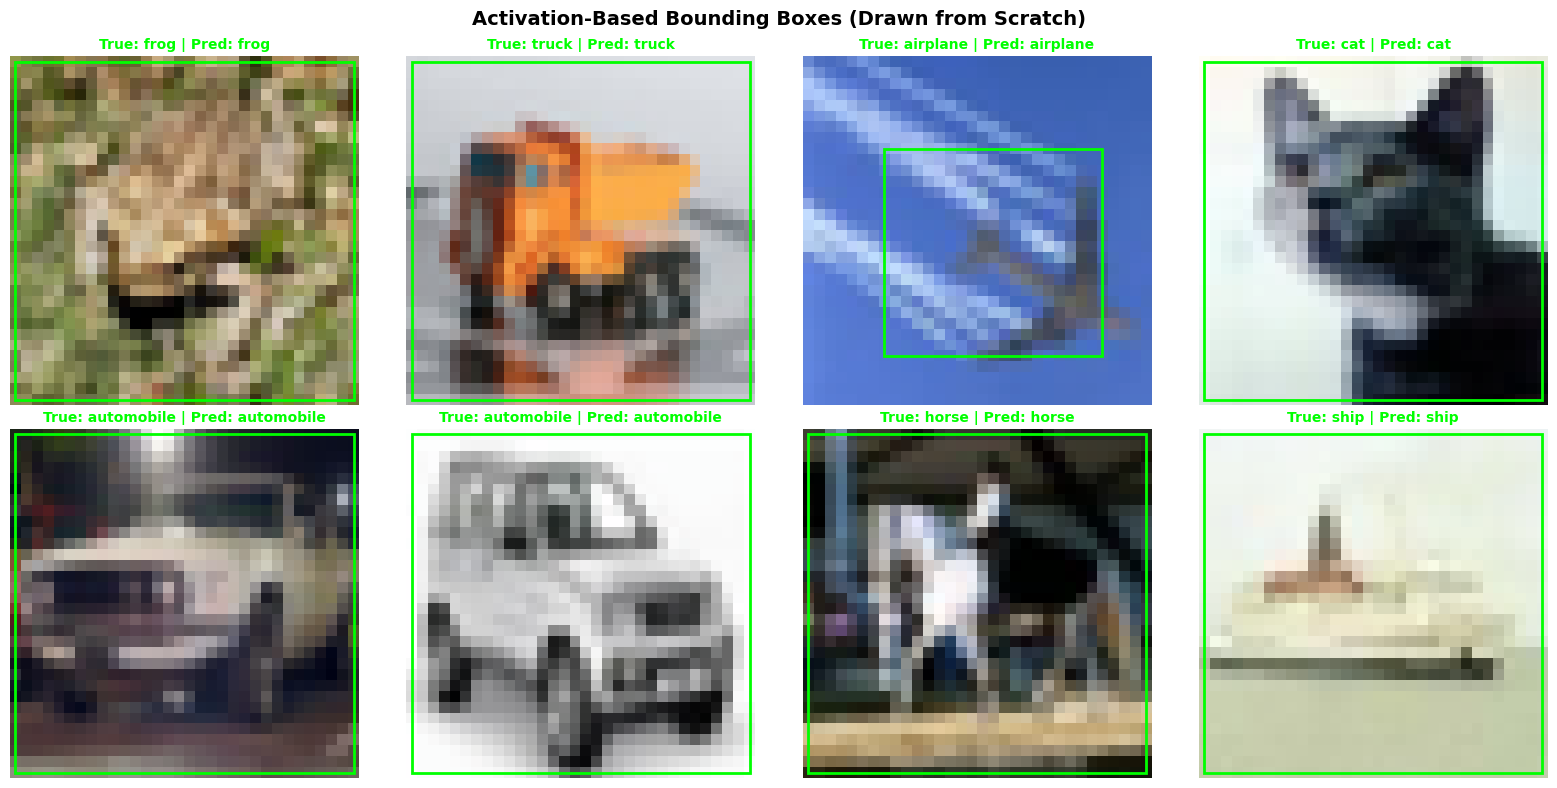

In [18]:
import torch.nn.functional as F

def activation_bbox(model, img_tensor, device=DEVICE, threshold=0.5):
    """Extract bounding box from last conv layer activations (no external libs)."""
    model.eval()
    activation = {}

    # Hook the last Conv2d layer
    last_conv = None
    for layer in model.features:
        if isinstance(layer, nn.Conv2d):
            last_conv = layer

    def hook(m, inp, out):
        activation['map'] = out.detach()
    handle = last_conv.register_forward_hook(hook)

    with torch.no_grad():
        out = model(img_tensor.unsqueeze(0).to(device))
    pred = out.argmax(1).item()
    handle.remove()

    # Build CAM: average over channels
    feat = activation['map'].squeeze(0)           # (C, H, W)
    cam = feat.mean(dim=0)                         # (H, W)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    # Resize to image size using PyTorch (no scipy needed)
    h, w = img_tensor.shape[1], img_tensor.shape[2]
    cam_resized = F.interpolate(cam.unsqueeze(0).unsqueeze(0),
                                size=(h, w), mode='bilinear',
                                align_corners=False).squeeze().cpu().numpy()

    # Threshold to get bounding box
    mask = cam_resized > threshold
    if mask.sum() == 0:
        mask = cam_resized > 0.3
    ys, xs = np.where(mask)
    if len(ys) == 0:
        bbox = (0, 0, w, h)
    else:
        bbox = (xs.min(), ys.min(), xs.max()-xs.min(), ys.max()-ys.min())

    return pred, bbox, cam_resized


# Draw bounding boxes on 8 test images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
indices = np.random.choice(len(test_vis), 8, replace=False)

for i, ax in enumerate(axes.flat):
    img, true_lbl = test_vis[indices[i]]
    pred, (bx, by, bw, bh), cam = activation_bbox(model, img)

    disp = img.permute(1, 2, 0).numpy()
    disp = disp * np.array(STD) + np.array(MEAN)
    disp = np.clip(disp, 0, 1)

    ax.imshow(disp)

    # Draw bounding box from scratch
    color = 'lime' if pred == true_lbl else 'red'
    rect = patches.Rectangle((bx, by), max(bw, 1), max(bh, 1),
                               linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    ax.set_title(f"True: {CLASSES[true_lbl]} | Pred: {CLASSES[pred]}",
                 color=color, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Activation-Based Bounding Boxes (Drawn from Scratch)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

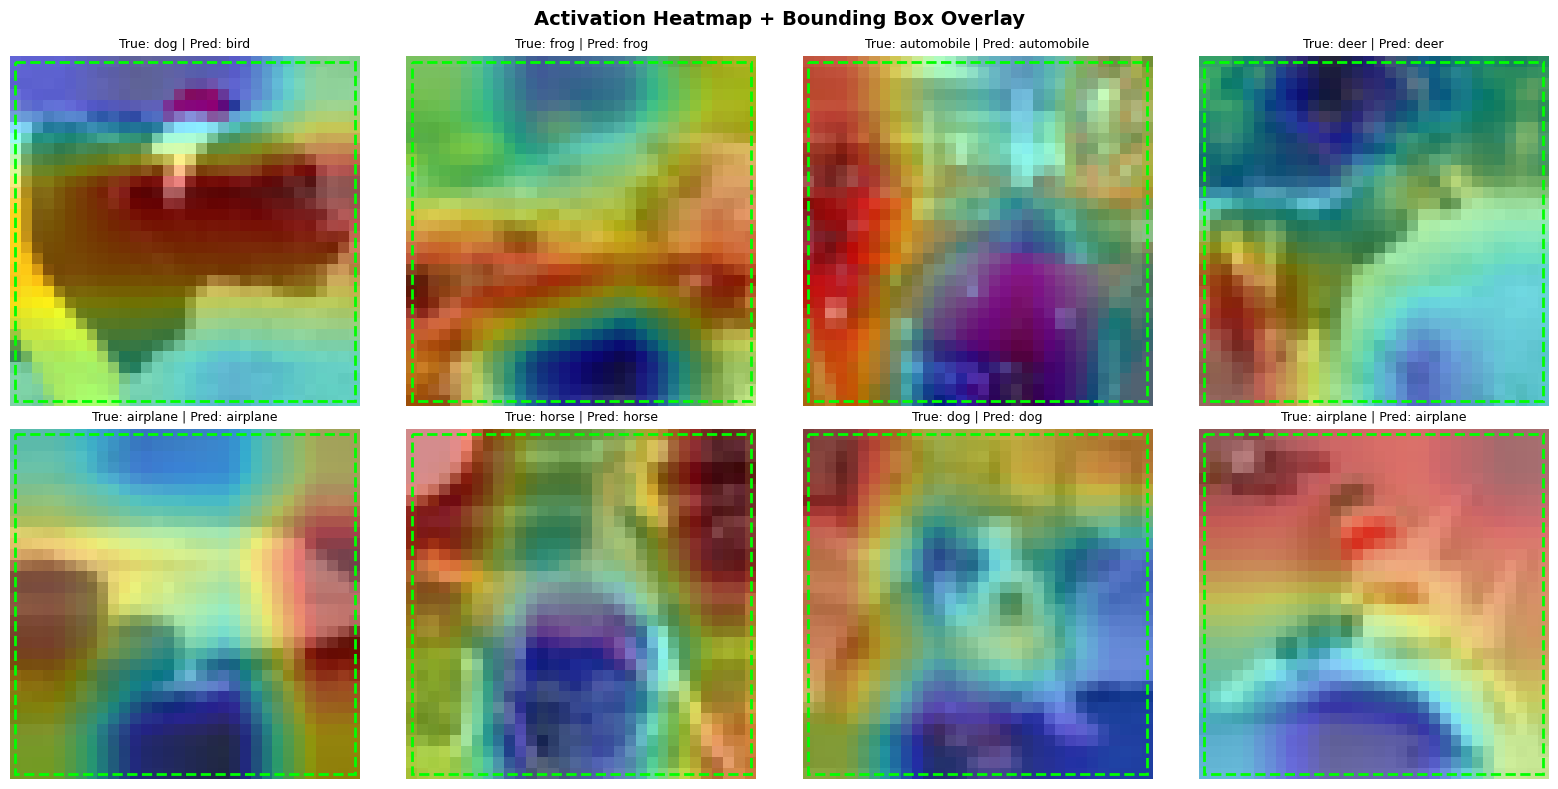

In [19]:
# Heatmap overlay + bounding box
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
indices = np.random.choice(len(test_vis), 8, replace=False)

for i, ax in enumerate(axes.flat):
    img, true_lbl = test_vis[indices[i]]
    pred, (bx, by, bw, bh), cam = activation_bbox(model, img, threshold=0.4)

    disp = img.permute(1, 2, 0).numpy()
    disp = disp * np.array(STD) + np.array(MEAN)
    disp = np.clip(disp, 0, 1)

    ax.imshow(disp)
    ax.imshow(cam, alpha=0.45, cmap='jet')

    rect = patches.Rectangle((bx, by), max(bw, 1), max(bh, 1),
                               linewidth=2, edgecolor='lime', facecolor='none', linestyle='--')
    ax.add_patch(rect)
    ax.set_title(f"True: {CLASSES[true_lbl]} | Pred: {CLASSES[pred]}", fontsize=9)
    ax.axis('off')

plt.suptitle('Activation Heatmap + Bounding Box Overlay',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

| Section | Details |
|---------|---------|
| **Dataset** | CIFAR-10: 50K train, 10K test, 10 classes |
| **Preprocessing** | Resize, Normalize, Augment (flip, crop, jitter, rotation) |
| **Model** | IntelCNN: 4 conv blocks (64->128->256->512) + BN + Dropout |
| **Training** | OneCycleLR, Early Stopping, Label Smoothing |
| **Hyperparameters** | Compared LR (0.0005/0.001/0.002), BS (32/64/128) |
| **Metrics** | Accuracy, Precision, Recall, F1-score (per class) |
| **Plots** | Loss/Acc curves, Confusion matrix, Per-class bars |
| **Predictions** | 4x4 grid with true vs predicted labels |
| **Bonus** | Activation-based bounding boxes (no external libs) |